# **End to End House price prediction**

There are 11 features and 506 rows.

Features are the following:

**CRIM:**	Per capita crime rate by town.

**Industry:**	Proportion of non-retail business acres per town.

**Airport:**	Airport near by (1 = near airport, 0 = otherwise).

**Air_pollution:** Air pollution level

**Avg_rooms:**	Average number of rooms per house.

**AGE:**	Average age in the area.

**DIS:**	Weighted distance to nearest shopping centres.

**hw_acc:**	Index of accessibility to highways (higher = better connectivity).

**TAX:**	Property tax rate.

**Education:**	Student-teacher ratio in the area (education quality indicator).

**LSTAT:**	Percentage of lower-status population (poverty indicator).

**med_price:**	Median value of owner-occupied homes in lakh (target variable).

**Goal:** Our goal is to develop a Linear Regression model which can predict the house prices. Buyers and Sellers can interpret the Linear Regression model. We can clearly visualize how each independent feature is associated with the price.

In [407]:
# imporitng packages
import pandas as pd
import numpy as np

In [408]:
# Loading the dataset
data = pd.read_csv('/content/bangalore_housing_data')
df = pd.DataFrame(data)
df

,crim,industry,airport,air_pollution,avg_rooms,age,dis,hw_acc,tax,education,lstat,med_price
0,0.00632,2.31,0,0.538,6.575,21.733333,4.0900,1,296,22.95,4.98,24.0
1,0.02731,7.07,0,0.469,6.421,26.300000,4.9671,2,242,26.70,9.14,21.6
2,0.02729,7.07,0,0.469,7.185,20.366667,4.9671,2,242,26.70,4.03,34.7
3,0.03237,2.18,0,0.458,6.998,15.266667,6.0622,3,222,28.05,2.94,33.4
4,0.06905,2.18,0,0.458,7.147,18.066667,6.0622,3,222,28.05,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,11.93,0,0.573,6.593,23.033333,2.4786,1,273,31.50,9.67,22.4
502,0.04527,11.93,0,0.573,6.120,25.566667,2.2875,1,273,31.50,9.08,20.6
503,0.06076,11.93,0,0.573,6.976,30.333333,2.1675,1,273,31.50,5.64,23.9
504,0.10959,11.93,0,0.573,6.794,29.766667,2.3889,1,273,31.50,6.48,22.0


In [409]:
# checking data types

df.dtypes

,0
crim,float64
industry,float64
airport,int64
air_pollution,float64
avg_rooms,float64
age,float64
dis,float64
hw_acc,int64
tax,int64
education,float64


In [410]:
# checking data statistics

df.describe()

,crim,industry,airport,air_pollution,avg_rooms,age,dis,hw_acc,tax,education,lstat,med_price
count,499.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.662681,11.136779,0.069170,0.554695,6.236395,22.858300,3.795043,9.549407,408.237154,27.683300,12.653063,22.532806
std,8.651675,6.860353,0.253994,0.115878,0.895295,9.382954,2.105710,8.707259,168.537116,3.247418,7.141062,9.197104
min,0.006320,0.460000,0.000000,0.385000,0.000000,0.966667,1.129600,1.000000,187.000000,18.900000,1.730000,5.000000
25%,0.082100,5.190000,0.000000,0.449000,5.879250,15.008333,2.100175,4.000000,279.000000,26.100000,6.950000,17.025000
50%,0.268380,9.690000,0.000000,0.538000,6.198500,25.833333,3.207450,5.000000,330.000000,28.575000,11.360000,21.200000
75%,3.695030,18.100000,0.000000,0.624000,6.618750,31.358333,5.188425,24.000000,666.000000,30.300000,16.955000,25.000000
max,88.976200,27.740000,1.000000,0.871000,8.780000,33.333333,12.126500,24.000000,711.000000,33.000000,37.970000,50.000000


## **Data Preprocessing**

In [411]:
# checking missing values

df.isnull().sum()

,0
crim,7
industry,0
airport,0
air_pollution,0
avg_rooms,0
age,0
dis,0
hw_acc,0
tax,0
education,0


In [412]:
# filling missing values

x = df.loc[df['crim'].isnull(), 'age'].tolist()

x


[2.2, 2.6, 2.0, 5.233333333333333, 5.833333333333333, 4.333333333333333, 5.9]

In [413]:
y = [i for i in df['age'] if i<6]

In [414]:
# filling th missing values with mean of age < 6
df['crim'] = df['crim'].fillna(np.mean(y))

In [415]:
df.isnull().sum()

,0
crim,0
industry,0
airport,0
air_pollution,0
avg_rooms,0
age,0
dis,0
hw_acc,0
tax,0
education,0


In [416]:
# Compute mean of non-zero values
mean_value = df[df['avg_rooms'] != 0]['avg_rooms'].mean()

# Replace 0s with this mean
df['avg_rooms'] = df['avg_rooms'].replace(0, mean_value)

## **Linear Regression assumption checking**

In [417]:
import matplotlib.pyplot as plt
import seaborn as sns

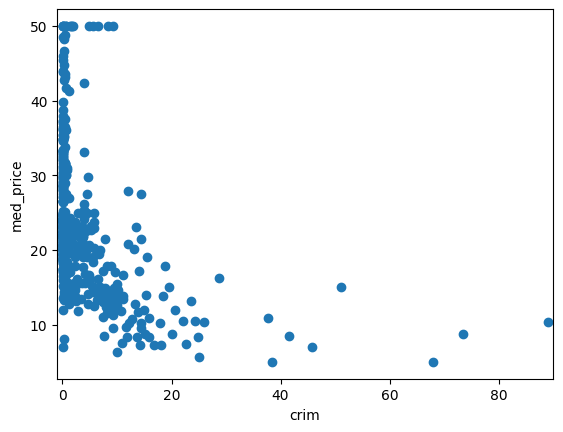

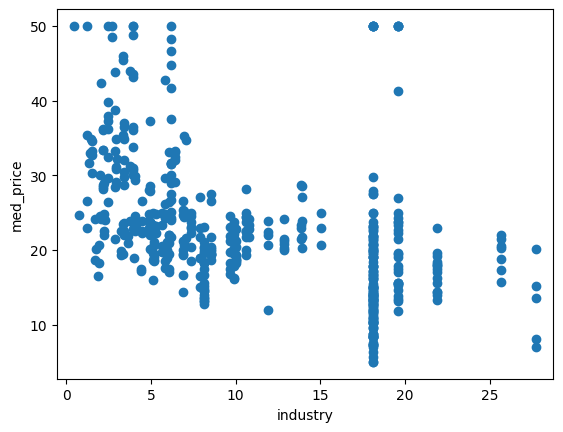

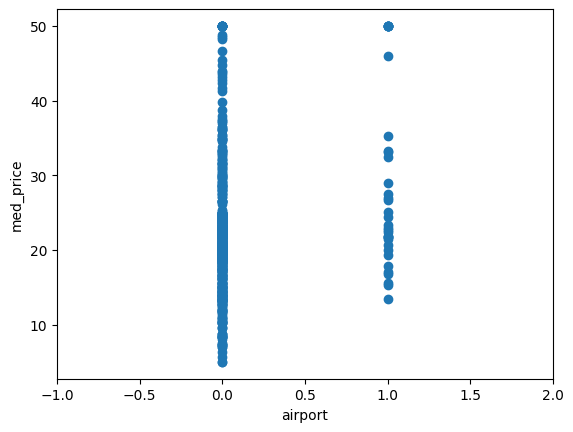

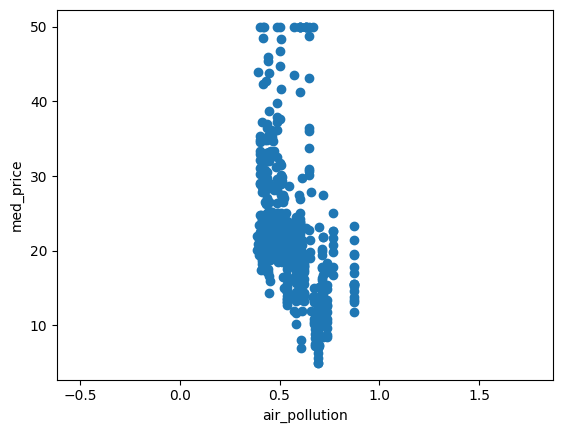

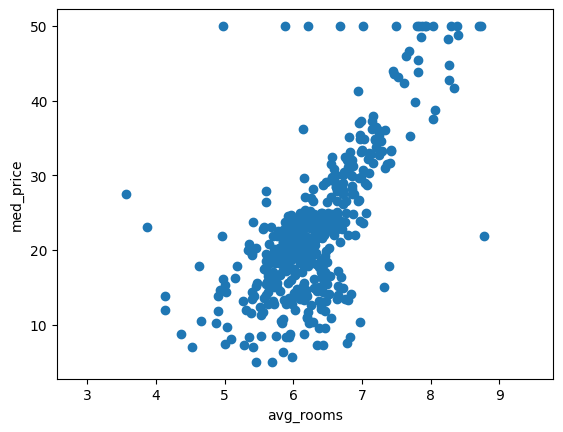

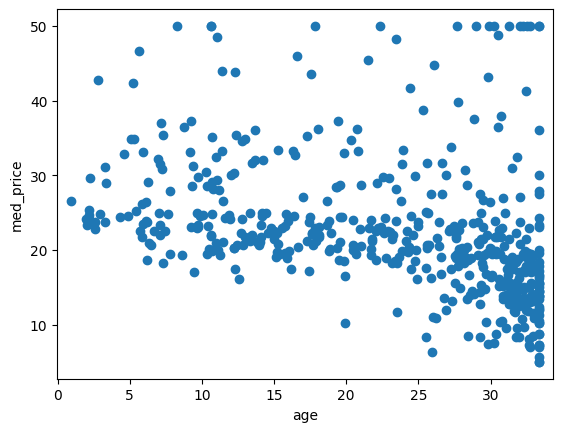

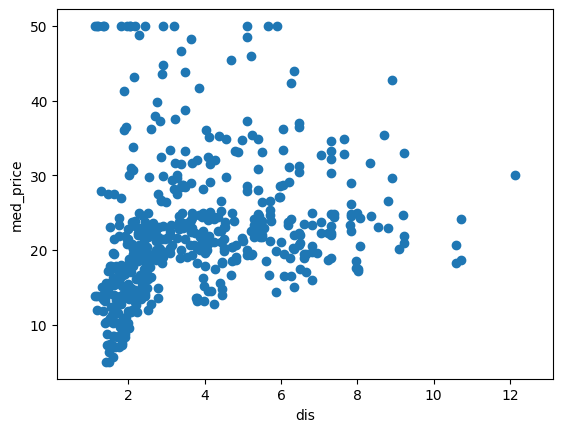

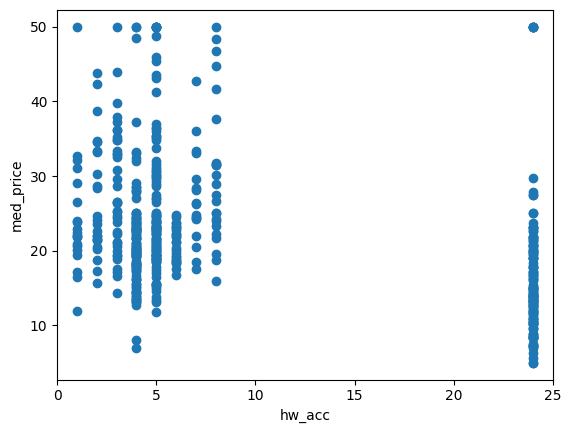

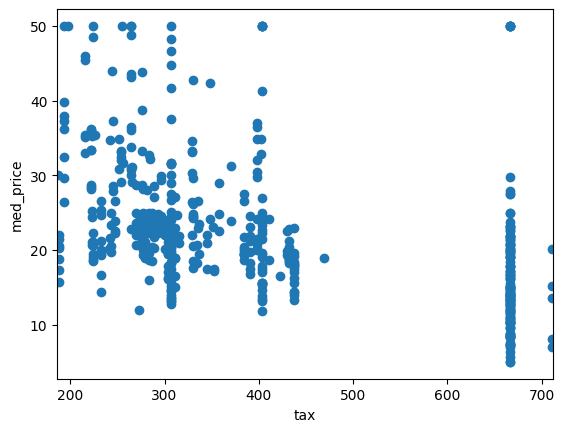

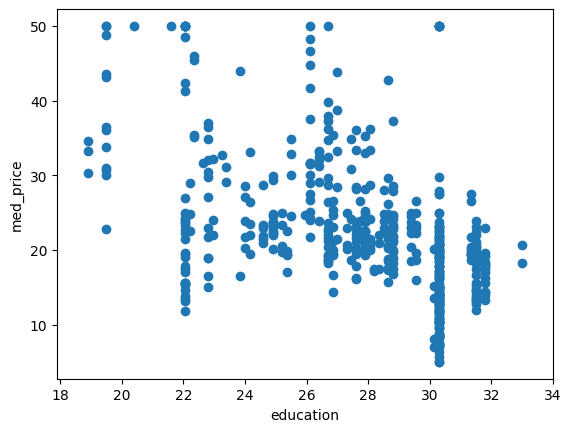

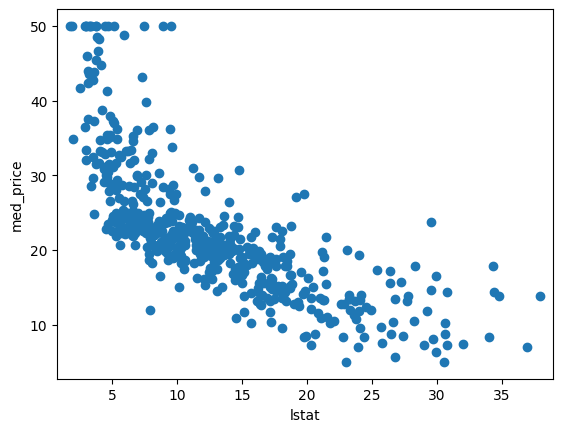

In [418]:
# checking linearity assumption with plots

for i in df.columns:
  if i!='med_price':
    plt.scatter(df[i],df['med_price'])
    plt.xlabel(f'{i}')
    plt.ylabel('med_price')
    plt.xlim(df[i].min() - 1, df[i].max() + 1)
    plt.show()

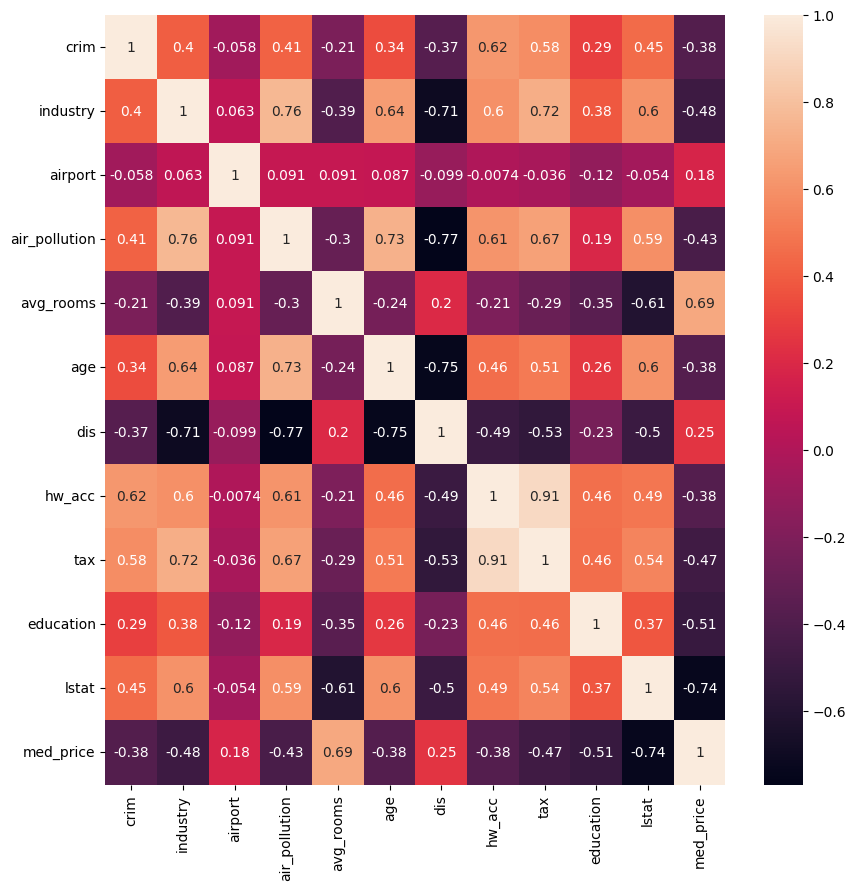

In [419]:
# checking pearson corrlations and multicollinearity
cor_mat = df.corr()
plt.figure(figsize = (10,10))
sns.heatmap(cor_mat,annot =True)
plt.show()

In [420]:
# dropping numerical feature which are uncorrelated with med_price(Threshold = 0.25)

df.drop(['dis'],axis = 1, inplace =True)
df

,crim,industry,airport,air_pollution,avg_rooms,age,hw_acc,tax,education,lstat,med_price
0,0.00632,2.31,0,0.538,6.575,21.733333,1,296,22.95,4.98,24.0
1,0.02731,7.07,0,0.469,6.421,26.300000,2,242,26.70,9.14,21.6
2,0.02729,7.07,0,0.469,7.185,20.366667,2,242,26.70,4.03,34.7
3,0.03237,2.18,0,0.458,6.998,15.266667,3,222,28.05,2.94,33.4
4,0.06905,2.18,0,0.458,7.147,18.066667,3,222,28.05,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,11.93,0,0.573,6.593,23.033333,1,273,31.50,9.67,22.4
502,0.04527,11.93,0,0.573,6.120,25.566667,1,273,31.50,9.08,20.6
503,0.06076,11.93,0,0.573,6.976,30.333333,1,273,31.50,5.64,23.9
504,0.10959,11.93,0,0.573,6.794,29.766667,1,273,31.50,6.48,22.0


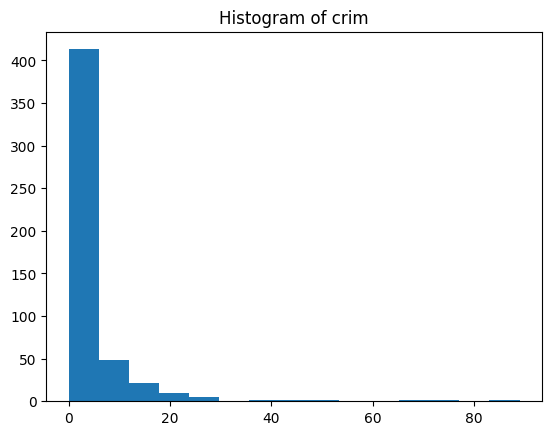

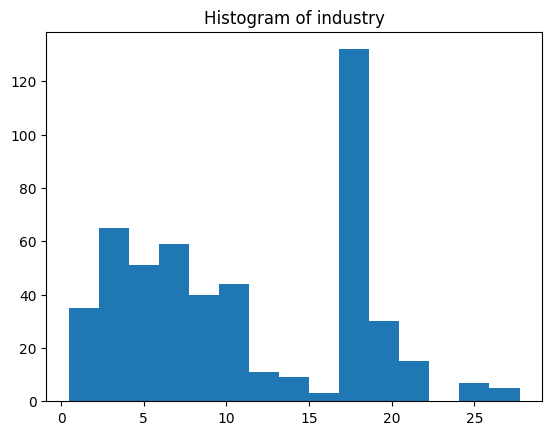

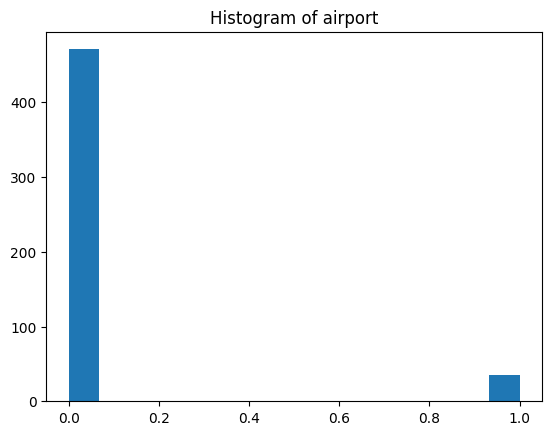

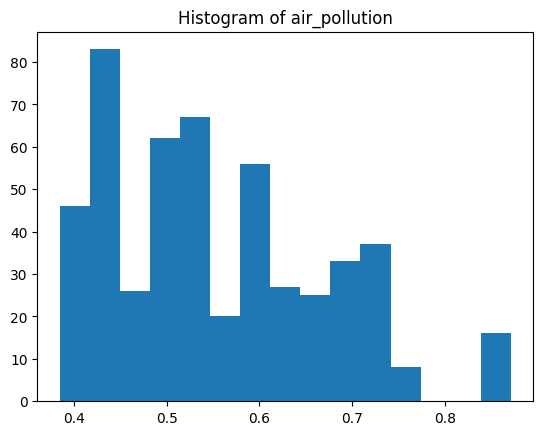

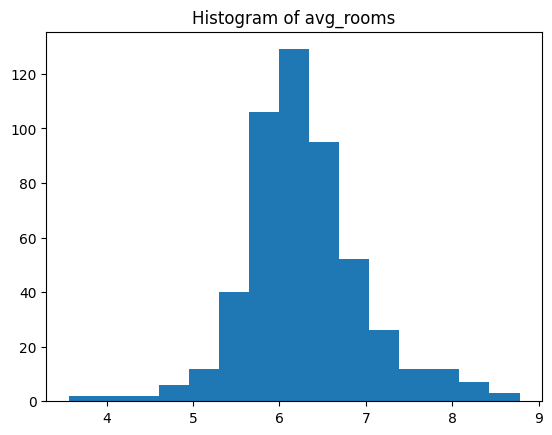

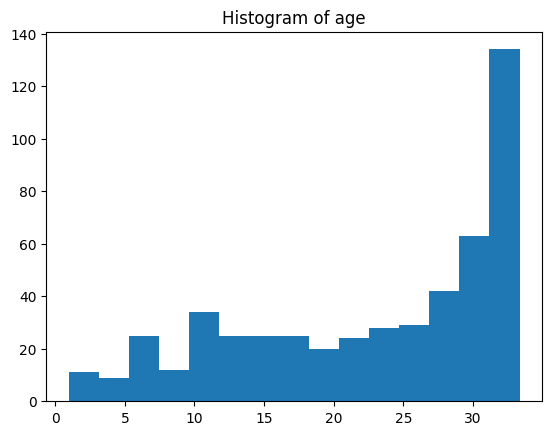

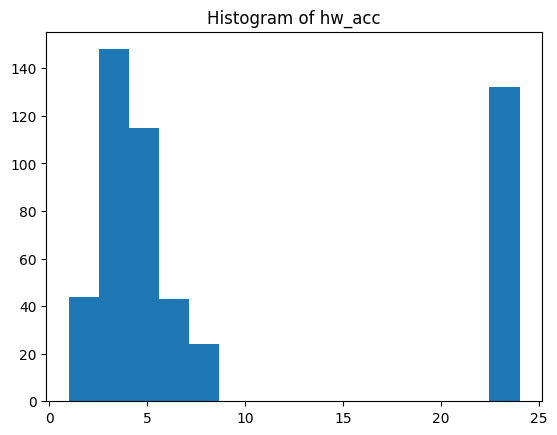

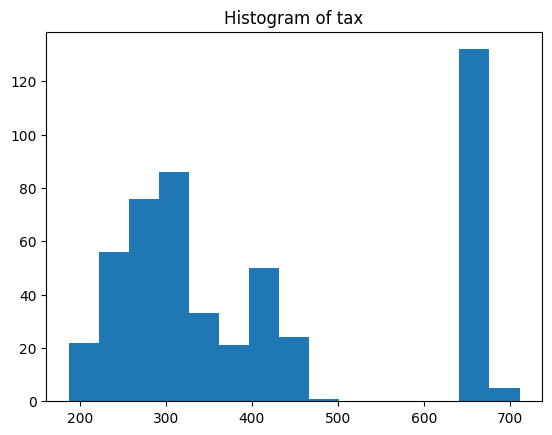

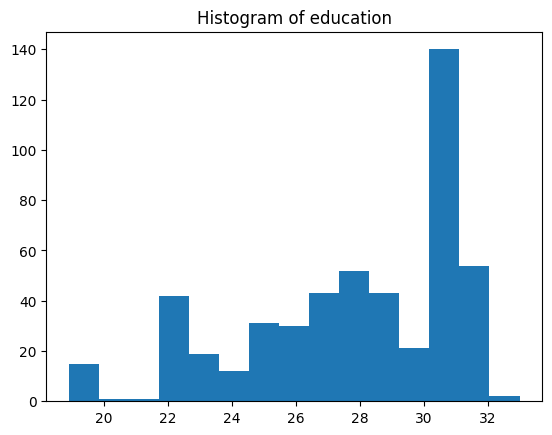

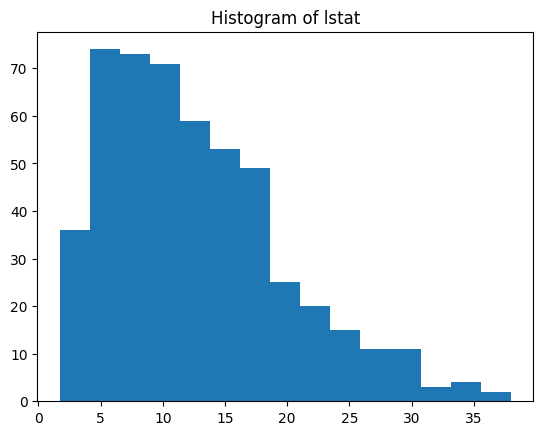

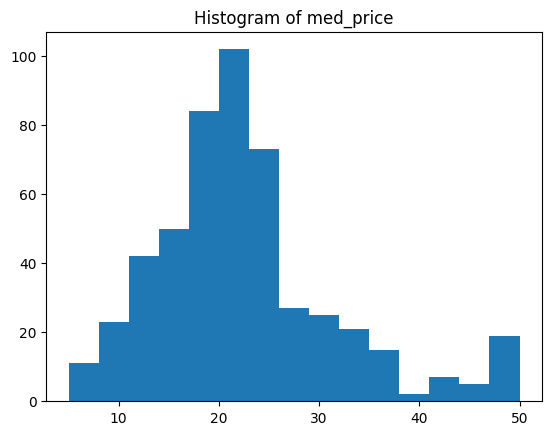

In [421]:
# checking normality


for i in df.columns:
    plt.hist(df[i],bins = int(2*len(df)**(1/3)))
    plt.title(f'Histogram of {i}')
    plt.show()


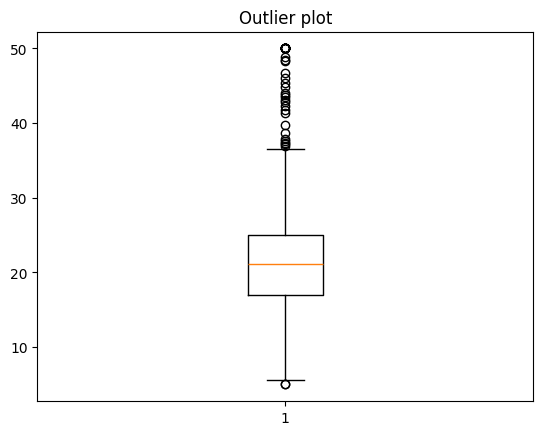

In [422]:
# checking outliers in target variable

plt.boxplot(df['med_price'])
plt.title('Outlier plot')
plt.show()

## **Model Building**

In [423]:
# splitting the data set
from sklearn.model_selection import train_test_split
Y = df['med_price']
X = df.drop(['med_price'],axis = 1)

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size = 0.3, random_state = 42)

In [424]:
# scaling the target variable
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler_Y = StandardScaler()

# Fit & Transform Y_train and Y_test
Y_train_scaled = scaler_Y.fit_transform(Y_train.values.reshape(-1, 1))
Y_test_scaled = scaler_Y.transform(Y_test.values.reshape(-1, 1))

In [425]:
# scaling train data
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler_X = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

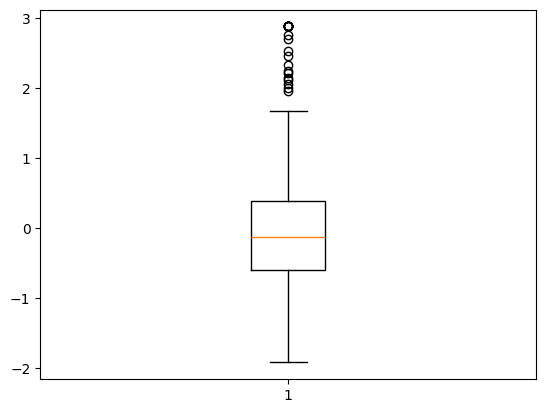

In [426]:
# Cheking outlier in target variable

plt.boxplot(Y_train_scaled)
plt.show()

In [427]:
Y_train_transformed = Y_train_scaled + 2
Y_test_transformed = Y_test_scaled + 2

In [428]:
# log transforming Y_train data

Y_train_log = np.log(Y_train_transformed)
Y_test_log = np.log(Y_test_transformed)

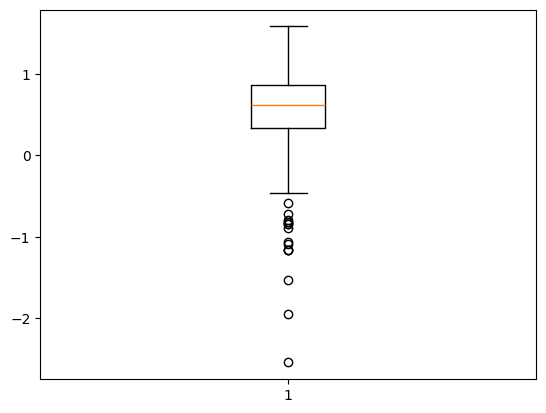

In [429]:
# box plot

plt.boxplot(Y_train_log)
plt.show()

In [430]:
# Model building

import statsmodels.api as sm

In [431]:
# Add a constant to the predictor variables
X_train_scaled = sm.add_constant(X_train_scaled)
X_test_scaled = sm.add_constant(X_test_scaled)

In [432]:
# Fitting the model
model = sm.OLS(Y_train_log, X_train_scaled).fit()

## **Evaluation**

In [433]:
from sklearn.metrics import r2_score

In [434]:
# Prediction on train set

X_train_pred = model.predict(X_train_scaled)


In [435]:
# evalution on train set

print(f'Train set r2_score: {r2_score(Y_train_log,X_train_pred)}')

Train set r2_score: 0.7481625535340694


In [436]:
# Prediction on teset set

X_test_pred = model.predict(X_test_scaled)

# evaluation on test set

print(f'Test set r2_score: {r2_score(Y_test_log,X_test_pred)}')

Test set r2_score: 0.7360643503820158


In [437]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     101.9
Date:                Wed, 26 Feb 2025   Prob (F-statistic):           2.36e-96
Time:                        08:45:37   Log-Likelihood:                -62.321
No. Observations:                 354   AIC:                             146.6
Df Residuals:                     343   BIC:                             189.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0887      0.110      9.924      0.0

## **Rebuilding the model**

In [438]:
# dropping features which are not significant (industry and age)

# splitting the data set
from sklearn.model_selection import train_test_split
Y = df['med_price']
X = df.drop(['med_price','age','industry'],axis = 1)

X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size = 0.3, random_state = 42)

In [439]:
# scaling train data
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler_X = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [440]:
# Add a constant to the predictor variables
X_train_scaled = sm.add_constant(X_train_scaled)
X_test_scaled = sm.add_constant(X_test_scaled)

In [441]:
# Fitting the model
model = sm.OLS(Y_train_log, X_train_scaled).fit()

In [442]:
# Prediction on train set

X_train_pred = model.predict(X_train_scaled)

In [443]:
# evalution on train set

print(f'Train set r2_score: {r2_score(Y_train_log,X_train_pred)}')

Train set r2_score: 0.7436346240897291


In [444]:
# Prediction on teset set

X_test_pred = model.predict(X_test_scaled)

# evaluation on test set

print(f'Test set r2_score: {r2_score(Y_test_log,X_test_pred)}')

Test set r2_score: 0.722183792614796


## **Pickling the model file**

In [445]:
import pickle

In [446]:
# Save the model using pickle
pickle.dump(model, open('regmodel.pkl', 'wb'))

In [447]:

pickled_model = pickle.load(open('regmodel.pkl', 'rb'))

In [448]:
# Save the scaler
with open('scaling.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)